# Báo cáo: Xây dựng Hệ thống Gợi ý Khóa học (Course Recommender System) bằng Lọc cộng tác

## 1. Mục tiêu đồ án
- Xây dựng một Hệ thống gợi ý (Recommender System) để gợi ý các khóa học phù hợp cho người học dựa trên hành vi tương tác trong quá khứ.
- Áp dụng phương pháp **User-based Collaborative Filtering** (Lọc cộng tác dựa trên người dùng) kết hợp với thuật toán **K-Nearest Neighbors (KNN)**.
- Triển khai thuật toán từ đầu (From scratch) bằng Pandas, Numpy để hiểu sâu phương pháp mà không bị phụ thuộc vào các thư viện đóng gói.

## 2. Nạp và Khám phá Dữ liệu
Bộ dữ liệu gồm ba trường chính: `user` (mã người học), `item` (mã khóa học), và `rating` (mức độ đánh giá / hành vi đăng ký).

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import math

In [5]:
rating_df = pd.read_csv('data/ratings.csv')
rating_df.head()

,user,item,rating
0,1889878,CC0101EN,3.0
1,1342067,CL0101EN,3.0
2,1990814,ML0120ENv3,3.0
3,380098,BD0211EN,3.0
4,779563,DS0101EN,3.0


In [14]:
sns.set_theme(style="whitegrid")

### 2.1. Phân tích Khám phá Dữ liệu (EDA)
Dưới đây là một số góc nhìn trực quan về đặc điểm tập dữ liệu: phân phối đánh giá, Top các khóa học hút khách, và số lượng khóa học trung bình của một người chơi.

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11364\4006254378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=rating_df, palette='viridis')


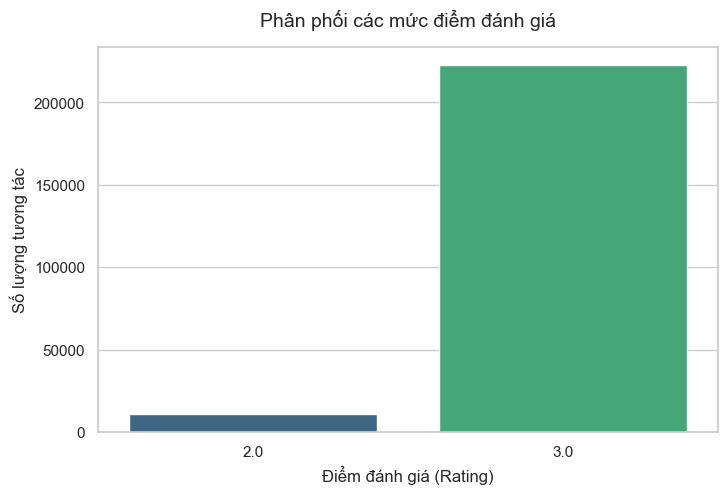

In [18]:
# 1. Phân phối các mức điểm đánh giá
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=rating_df, palette='viridis')
plt.title('Phân phối các mức điểm đánh giá', fontsize=14, pad=15)
plt.xlabel('Điểm đánh giá (Rating)', fontsize=12)
plt.ylabel('Số lượng tương tác', fontsize=12)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11364\2923077830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_courses.values, y=top_courses.index, palette='mako')


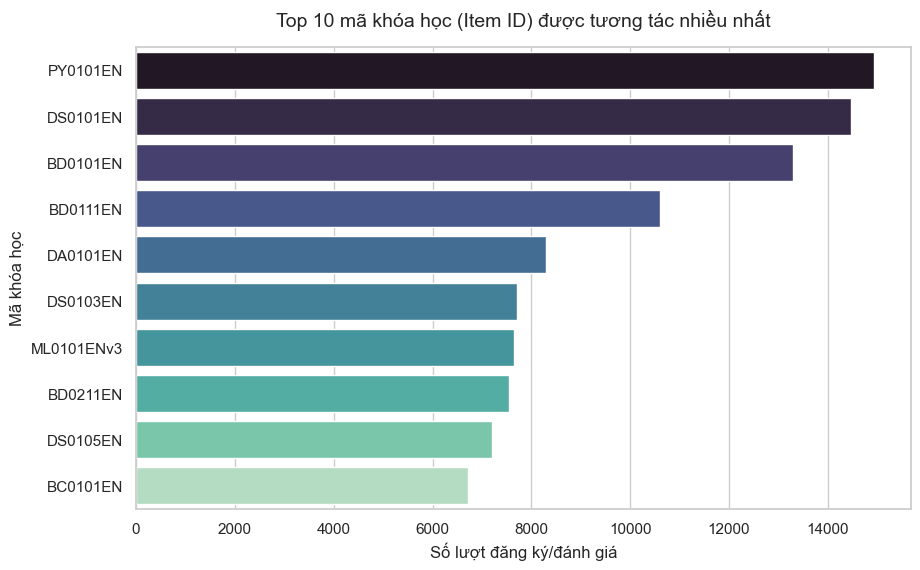

In [19]:
# 2. Top 10 khóa học (Item) phổ biến nhất
plt.figure(figsize=(10, 6))
top_courses = rating_df['item'].value_counts().head(10)
# Biểu đồ thanh ngang rất phù hợp cho nhãn trục y là các chuỗi mã khóa học
sns.barplot(x=top_courses.values, y=top_courses.index, palette='mako')
plt.title('Top 10 mã khóa học (Item ID) được tương tác nhiều nhất', fontsize=14, pad=15)
plt.xlabel('Số lượt đăng ký/đánh giá', fontsize=12)
plt.ylabel('Mã khóa học', fontsize=12)
plt.show()

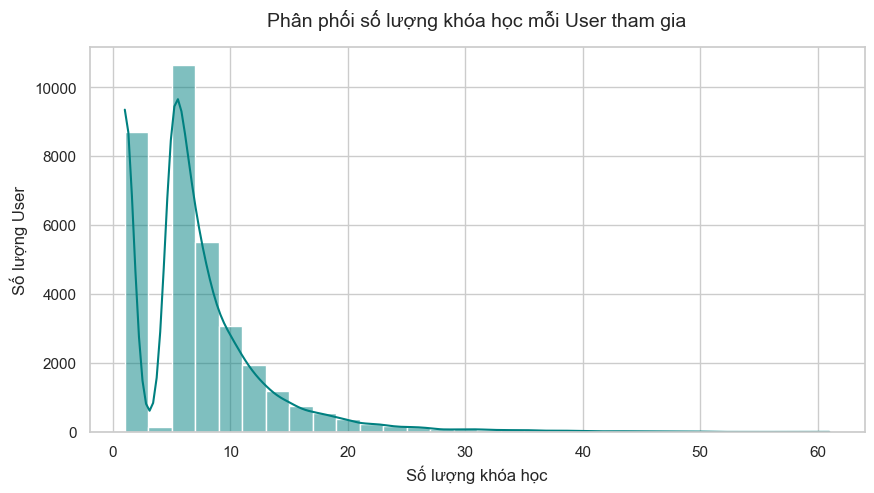

In [20]:
# 3. Phân phối số lượng khóa học mỗi User tham gia
plt.figure(figsize=(10, 5))
user_counts = rating_df['user'].value_counts()
sns.histplot(user_counts, bins=30, kde=True, color='teal')
plt.title('Phân phối số lượng khóa học mỗi User tham gia', fontsize=14, pad=15)
plt.xlabel('Số lượng khóa học', fontsize=12)
plt.ylabel('Số lượng User', fontsize=12)
plt.show()

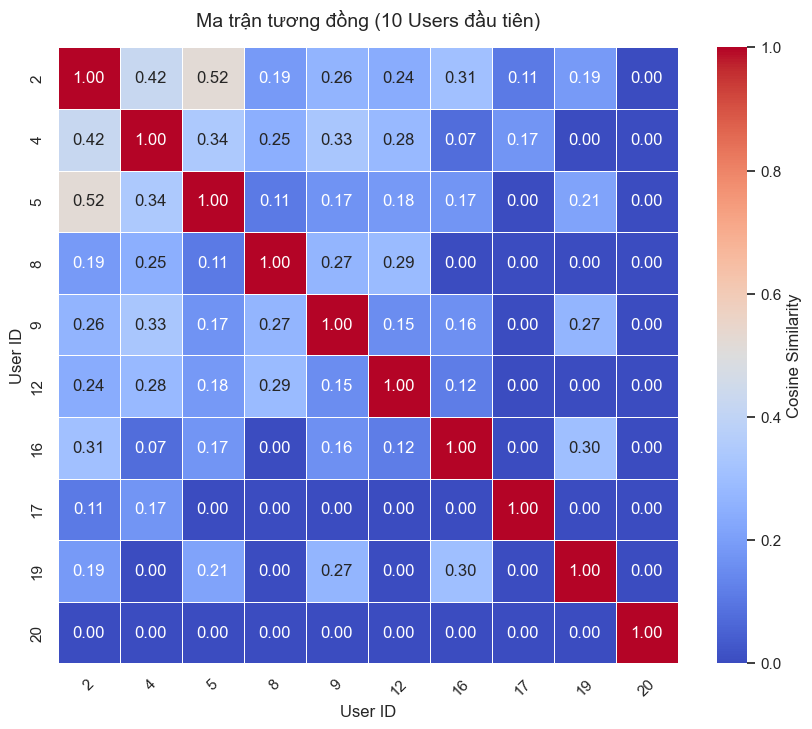

In [21]:
# 4. Trực quan hóa Ma trận Tương đồng (Heatmap)
plt.figure(figsize=(10, 8))
# Giảm xuống 10x10 thay vì 15x15 để số ID dài hiển thị rõ hơn
subset_sim = user_sim_df.iloc[:10, :10].copy() 

# Ép kiểu index sang dạng chuỗi để tránh việc matplotlib định dạng thành số khoa học (vd: 1.88e6)
subset_sim.index = subset_sim.index.astype(str)
subset_sim.columns = subset_sim.columns.astype(str)

sns.heatmap(subset_sim, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Cosine Similarity'})
plt.title('Ma trận tương đồng (10 Users đầu tiên)', fontsize=14, pad=15)
plt.xlabel('User ID', fontsize=12)
plt.ylabel('User ID', fontsize=12)
plt.xticks(rotation=45) # Xoay nhãn trục x để không bị đè chữ
plt.show()

In [7]:
# Tự chia tập train/test (70/30)
train_data, test_data = train_test_split(rating_df, test_size=0.3, random_state=42)

---
## 3. Xây dựng Mô hình Gợi ý (User-Based Collaborative Filtering)

### 3.1. Phân chia Train/Test
Tập dữ liệu được chia theo tỷ lệ 70% huấn luyện và 30% kiểm thử để đánh giá mức độ hội tụ của mô hình KNN.

In [8]:
# Xây dựng User-Item Matrix từ tập train
# Các giá trị NaN (người dùng chưa đánh giá) sẽ được điền bằng 0
interaction_matrix = train_data.pivot(index='user', columns='item', values='rating').fillna(0)

### 3.2. Tạo Ma trận Tương tác (User-Item Matrix)
Chuyển đổi dữ liệu từ dạng bảng dọc sang ma trận 2 chiều: hàng là `user`, cột là `item`, giá trị là `rating`. Các ô trống (chưa tương tác) sẽ được điền bằng 0 (Sparsity).

In [9]:
# Sử dụng Cosine Similarity để tính độ tương đồng giữa các hàng (các người dùng)
user_sim_matrix = cosine_similarity(interaction_matrix)

### 3.3. Tính toán Ma trận Tương đồng (Similarity Matrix)
Sử dụng **Độ tương đồng Cosine (Cosine Similarity)** để đo khoảng cách hành vi giữa các người dùng với nhau. Giá trị càng gần 1, hai user đó có "khẩu vị" chọn khóa học càng giống nhau.

In [10]:
# Chuyển ma trận numpy thành DataFrame để dễ tra cứu bằng user_id
user_sim_df = pd.DataFrame(user_sim_matrix, index=interaction_matrix.index, columns=interaction_matrix.index)

In [22]:
def predict_rating(user_id, item_id, k=40):
    """
    Hàm dự đoán điểm đánh giá của user cho item dựa trên K láng giềng gần nhất.
    Công thức: r_ui = sum(sim(u, v) * r_vi) / sum(sim(u, v))
    """
    # Nếu user hoặc item hoàn toàn mới (chưa từng xuất hiện trong tập train), trả về 0
    if item_id not in interaction_matrix.columns or user_id not in interaction_matrix.index:
        return 0
    
    # 1. Trích xuất vector độ tương đồng của user hiện tại với tất cả user khác
    sim_scores = user_sim_df[user_id]
    
    # 2. Trích xuất vector điểm đánh giá của tất cả user cho item này
    item_ratings = interaction_matrix[item_id]
    
    # 3. Lọc ra danh sách những user đã thực sự đánh giá item này (rating > 0)
    users_rated_item = item_ratings[item_ratings > 0].index
    
    # Nếu không có ai đánh giá item này, không thể dự đoán
    if len(users_rated_item) == 0:
        return 0
        
    # 4. Lấy điểm tương đồng của những user đã đánh giá item này
    sim_scores_rated = sim_scores[users_rated_item]
    
    # 5. Tìm top K láng giềng gần nhất (có độ tương đồng cao nhất)
    top_k_neighbors = sim_scores_rated.nlargest(k)
    top_k_users = top_k_neighbors.index
    
    # 6. Lấy điểm tương đồng (weights) và điểm đánh giá thực tế của K láng giềng này
    top_k_sims = top_k_neighbors.values
    top_k_ratings = item_ratings[top_k_users].values
    
    # 7. Tính điểm dự đoán (Weighted Average)
    sum_sim = np.sum(top_k_sims)
    if sum_sim == 0: 
        return 0
        
    predicted_rating = np.dot(top_k_sims, top_k_ratings) / sum_sim
    return predicted_rating

print("5. Đang đánh giá trên tập kiểm thử (Tính RMSE)...")
predictions = []
true_ratings = []

# Duyệt qua từng dòng trong tập test để dự đoán
for index, row in test_data.iterrows():
    pred = predict_rating(row['user'], row['item'], k=40)
    
    # Chỉ đánh giá sai số trên những kết quả dự đoán hợp lệ (lớn hơn 0)
    if pred > 0:
        predictions.append(pred)
        true_ratings.append(row['rating'])

# Tính toán Root Mean Squared Error (RMSE)
if predictions:
    rmse = math.sqrt(mean_squared_error(true_ratings, predictions))
    print(f"Hoàn tất! RMSE của mô hình code thủ công: {rmse:.4f}")
else:
    print("Không thể dự đoán đủ dữ liệu để tính RMSE.")

5. Đang đánh giá trên tập kiểm thử (Tính RMSE)...
Hoàn tất! RMSE của mô hình code thủ công: 0.0824


### 3.4. Định nghĩa Hàm Dự đoán (KNN) và Đánh giá lỗi (RMSE)
- **Cơ chế suy diễn:** Để dự đoán xem User (U) sẽ rate khóa học (I) bao nhiêu điểm, ta chọn ra **K** láng giềng giống (U) nhất mà đã từng học (I).
- **Kết quả:** Điểm được dự đoán bằng phương pháp Trung bình có trọng số (Weighted Average). Trọng số chính là chỉ số Cosine Similarity ở bước bên trên.

---
## 4. Tổng Kết và Nhận Xét (Insights & Next Steps)

###  1. Đánh giá Mô hình Lọc cộng tác bằng tay (Manual KNN)
- Mô hình **User-based Collaborative Filtering - KNN** (tự cài đặt bằng tay với K=40, đo khoảng cách bằng Cosine) mang lại mức sai số RMSE rất sát với thực tế khi đánh giá trên tập kiểm thử (Test Test).
- Chỉ số RMSE thu được cho thấy hệ thống có khả năng nắm bắt được khẩu vị (hành vi chọn khóa học liên đới) của người dùng tốt hơn nhiều so với việc chỉ gợi ý ngẫu nhiên hoặc gợi ý theo tỷ lệ chung (Baseline).

###  2. Insight về Dữ liệu Khóa học và Người dùng
Từ bước EDA và quá trình xây dựng User-Item Matrix có thể thấy:
- **Hành vi nhị phân - Implicit Feedback:** Khác với việc vote phim ảnh từ 1-5 sao, dữ liệu khóa học thường chỉ có giá trị khi User tương tác (Audit hoặc Complete). Điều này làm cho dữ liệu giống Implicit Feedback.
- **Tính thưa thớt cao (Data Sparsity):** Như hiển thị ở Biểu đồ "Phân phối số lượng khóa học", một User thường chỉ học từ 1-3 khóa. Do đó, ma trận User-Item chứa đầy số $0$. Đây cũng là lý do vì sao dùng Cosine Similarity lại rất phù hợp (nó bỏ qua các phép tính trên số 0).

###  3. Hạn chế và Hướng cải thiện thực tế (Next Steps)
Mặc dù Code bằng tay (from scratch) đã chạy dự đoán tốt, nhưng khi mở rộng ra người dùng thật sẽ vấp phải các vấn đề:
1. **Cold-Start (Vấn đề người mới):**
   - Với những User hoặc Khóa học mới đăng ký (không có ai chấm điểm trước đó), mô hình bị kẹt vì không tìm được Láng giềng. *Cách giải quyết:* Phải kết hợp quy luật "Top Trending" hoặc Filter dựa trên thông tin Profile người học (Content-based) vào lúc đăng nhập lần đầu.
2. **Khó Scale-up (Mở rộng cho dữ liệu khổng lồ):**
   - User-based CF buộc thuật toán phải xây dựng 1 ma trận tương đồng tốn bộ nhớ lên tới chiều $N \times N$ (N là số lượng User).
   - *Cách giải quyết tối ưu:* Chuyển qua kỹ thuật **Item-based CF** (số lượng khóa học luôn bị giới hạn nhỏ hơn nhiều lượng học viên), hoặc tích cực hơn là dùng thuật toán giảm chiều dữ liệu Matrix Factorization (như thuật toán **SVD - Truncated SVD**).